# **<span style="font-family: Arial">Facebook Page Performance - Data Transformation </span>**


**Author:** Ozor Moya

**Date:** 08/08/2026

---
### 1. Import libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

---
### 2. Load cleaned dataset

In [3]:
df = pd.read_csv('/Users/sa02/class-projects/EOP-Project/P1PortfolioProject/Data/cleaned_facebook.csv')

In [3]:
df.head()

,page_likes,post_type,category,post_month,post_weekday,post_hour,paid,total_reach,total_impressions,engaged_users,post_consumers,post_consumptions,fan_impressions,fan_reach,fan_engaged,comments,likes,shares,total_interactions
0,139441,Photo,2,12,4,3,0,2752,5091,178,109,159,3078,1640,119,4,79,17,100
1,139441,Status,2,12,3,10,0,10460,19057,1457,1361,1674,11710,6112,1108,5,130,29,164
2,139441,Photo,3,12,3,3,0,2413,4373,177,113,154,2812,1503,132,0,66,14,80
3,139441,Photo,2,12,2,10,1,50128,87991,2211,790,1119,61027,32048,1386,58,1572,147,1777
4,139441,Photo,2,12,2,3,0,7244,13594,671,410,580,6228,3200,396,19,325,49,393


---
### 3. Renaming all features

In [4]:
df.columns = [ 
    'page_likes',
    'post_type',
    'category',
    'post_month',
    'post_weekday',
    'post_hour',
    'paid',
    'total_reach',
    'total_impressions',
    'engaged_users',
    'post_consumers',
    'post_consumptions',
    'fan_impressions',
    'fan_reach',
    'fan_engaged',
    'comments',
    'likes',
    'shares',
    'total_interactions'
]

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   page_likes          500 non-null    int64 
 1   post_type           500 non-null    object
 2   category            500 non-null    int64 
 3   post_month          500 non-null    int64 
 4   post_weekday        500 non-null    int64 
 5   post_hour           500 non-null    int64 
 6   paid                500 non-null    int64 
 7   total_reach         500 non-null    int64 
 8   total_impressions   500 non-null    int64 
 9   engaged_users       500 non-null    int64 
 10  post_consumers      500 non-null    int64 
 11  post_consumptions   500 non-null    int64 
 12  fan_impressions     500 non-null    int64 
 13  fan_reach           500 non-null    int64 
 14  fan_engaged         500 non-null    int64 
 15  comments            500 non-null    int64 
 16  likes               500 no

- Standardise to `snake_case`. This is identical to what I did in EDA — but I include it here so this notebook is **self-contained and reproducible**.

---
### 4. Datatype Fix and Missing value imputation

In [5]:
df['paid']   = df['paid'].fillna(0).astype(int)
df['likes']  = df['likes'].fillna(df['likes'].median()).astype(int)
df['shares'] = df['shares'].fillna(df['shares'].median()).astype(int)

---
### 5. Feature Engineering

In [6]:
# 5.1 Engagement Rate 
# Division — protect against divide-by-zero with .replace(0, NaN)
df['engagement_rate'] = (
    df['engaged_users'] / df['total_reach'].replace(0, np.nan)
).round(6)

print(f'engagement_rate — range: {df.engagement_rate.min():.4f} to {df.engagement_rate.max():.4f}')
print(f'  mean: {df.engagement_rate.mean():.4f}, median: {df.engagement_rate.median():.4f}')


engagement_rate — range: 0.0049 to 0.6008
  mean: 0.1243, median: 0.1217


In [7]:
# 5.2 Is Weekend
# weekday: 1=Mon, 2=Tue, ..., 6=Sat, 7=Sun

df['is_weekend'] = df['post_weekday'].isin([6, 7]).astype(int)

print(f'Weekend posts: {df.is_weekend.sum()} ({df.is_weekend.mean()*100:.1f}%)')
print(f'Weekday posts: {(df.is_weekend==0).sum()} ({(df.is_weekend==0).mean()*100:.1f}%)')

Weekend posts: 163 (32.6%)
Weekday posts: 337 (67.4%)


In [8]:
# 5.3 Log-Transformed Numeric Features
# Many reach/impression columns are also right-skewed
# Log-transforming them reduces the scale and skew, helping linear models

log_cols = ['total_reach', 'total_impressions', 'fan_reach', 'fan_impressions',
            'engaged_users', 'page_likes']

for col in log_cols:
    new_col = f'log_{col}'
    df[new_col] = np.log1p(df[col])

print('Log-transformed features created:')
print([f'log_{c}' for c in log_cols])

Log-transformed features created:
['log_total_reach', 'log_total_impressions', 'log_fan_reach', 'log_fan_impressions', 'log_engaged_users', 'log_page_likes']


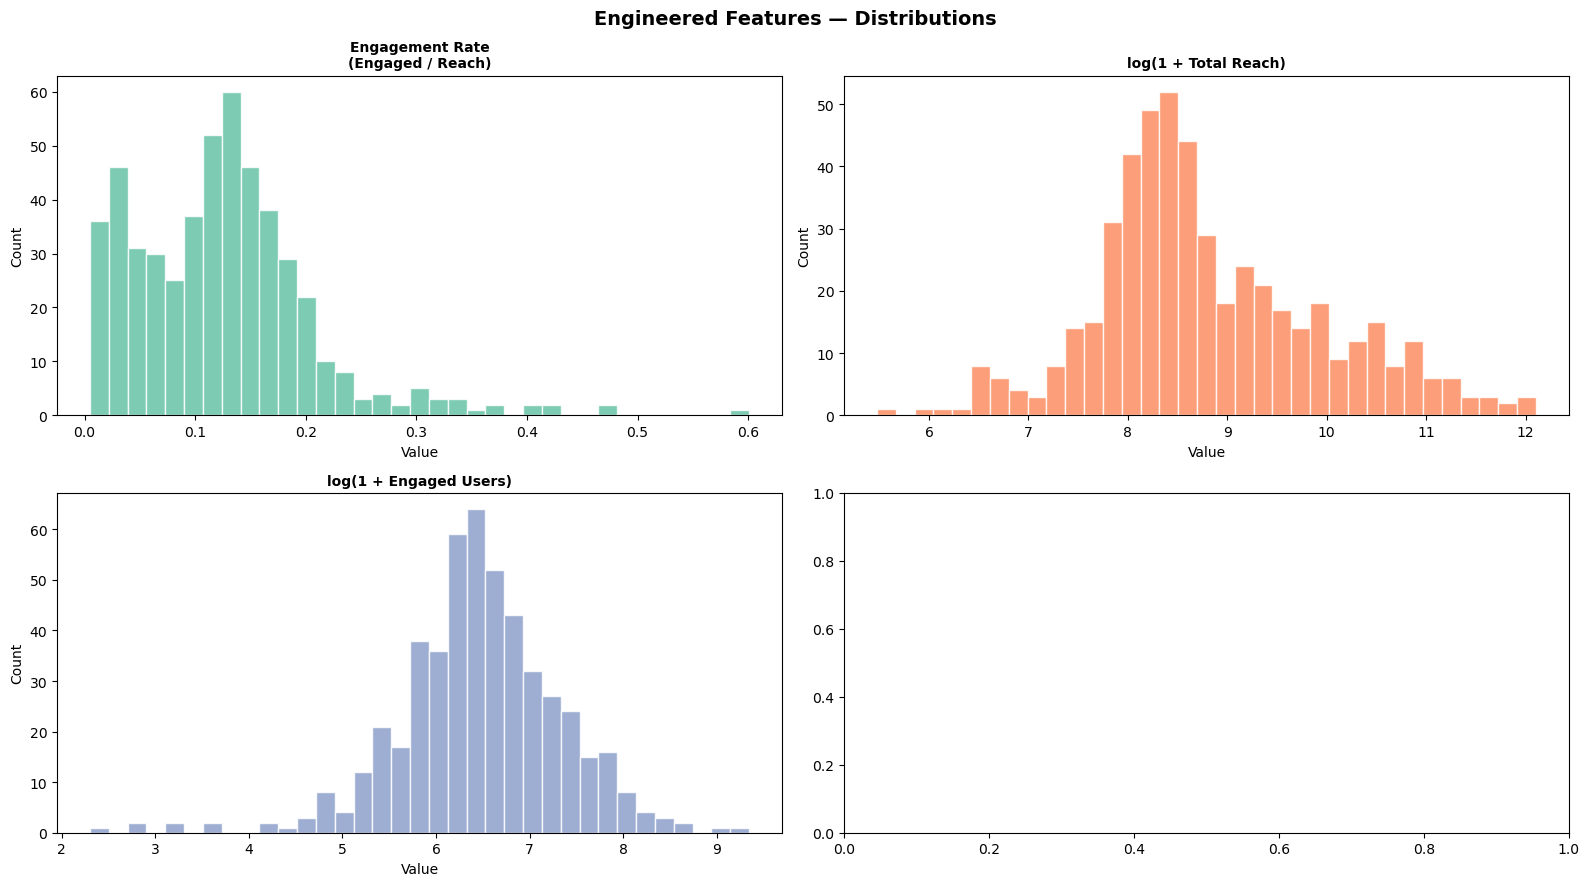

In [9]:
# Visualise the engineered features
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
axes = axes.flatten()

eng_features = [
    ('engagement_rate',  'Engagement Rate\n(Engaged / Reach)'),
    ('log_total_reach',  'log(1 + Total Reach)'),
    ('log_engaged_users','log(1 + Engaged Users)')
]

colors = sns.color_palette('Set2', 6)
for i, (col, title) in enumerate(eng_features):
    if df[col].dtype == 'object':
        vc = df[col].value_counts()
        axes[i].bar(vc.index, vc.values, color=colors[i], edgecolor='white')
    else:
        axes[i].hist(df[col].dropna(), bins=35, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(title, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

fig.suptitle('Engineered Features — Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/fig_11_engineered_features.png', bbox_inches='tight')
plt.show()

---
### 6. Categorical Encoding

In [10]:
print('Before encoding:')
print(f'  post_type unique values:  {df.post_type.unique()}')
print(f'  Shape: {df.shape}')

# One-hot encode both nominal categorical columns
# drop_first=True avoids the dummy variable trap
df = pd.get_dummies(df, columns=['post_type'],
                    prefix=['type',], drop_first=True)

print('\nAfter encoding:')
print(f'  Shape: {df.shape}')
new_dummy_cols = [c for c in df.columns if c.startswith(('type_'))]
print(f'  New columns: {new_dummy_cols}')

Before encoding:
  post_type unique values:  ['Photo' 'Status' 'Link' 'Video']
  Shape: (500, 27)

After encoding:
  Shape: (500, 29)
  New columns: ['type_Photo', 'type_Status', 'type_Video']


In [11]:
# Convert boolean dummy columns to int (0/1) for cleaner output
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)
print(f'Converted {len(bool_cols)} boolean columns to int: {list(bool_cols)}')

Converted 3 boolean columns to int: ['type_Photo', 'type_Status', 'type_Video']


---
### 7. Target Transformation

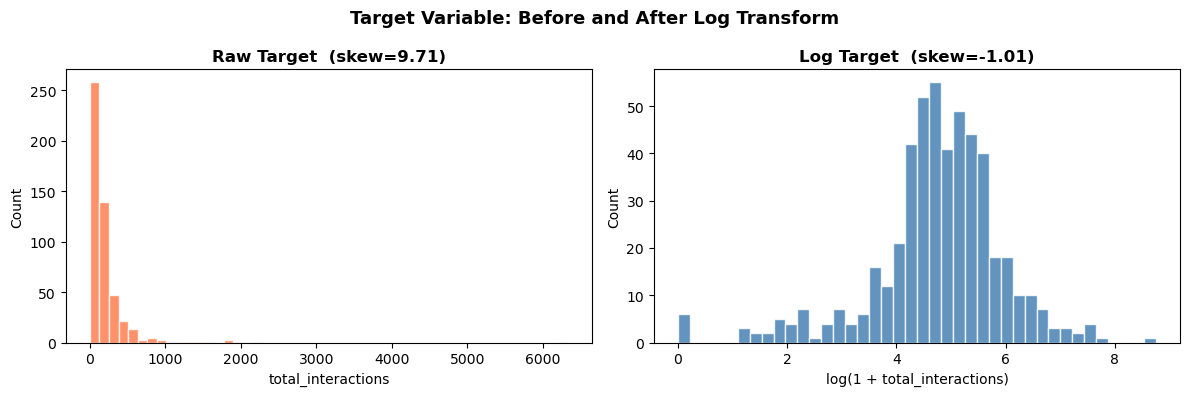

Skewness reduced: 9.71 → -1.01


In [12]:
df['log_total_interactions'] = np.log1p(df['total_interactions'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['total_interactions'], bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[0].set_title(f'Raw Target  (skew={df.total_interactions.skew():.2f})', fontweight='bold')
axes[0].set_xlabel('total_interactions')

axes[1].hist(df['log_total_interactions'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Log Target  (skew={df.log_total_interactions.skew():.2f})', fontweight='bold')
axes[1].set_xlabel('log(1 + total_interactions)')

for ax in axes:
    ax.set_ylabel('Count')

fig.suptitle('Target Variable: Before and After Log Transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/fig_12_target_transform.png', bbox_inches='tight')
plt.show()

print(f'Skewness reduced: {df.total_interactions.skew():.2f} → {df.log_total_interactions.skew():.2f}')

---
### 8. Remove Leakage Features

In [13]:
cols_to_drop = ['comments', 'likes', 'shares', 'total_interactions']
df = df.drop(columns=cols_to_drop)

print(f'Dropped: {cols_to_drop}')
print(f'Shape after dropping: {df.shape}')
print(f'\nRemaining columns:')
for col in df.columns:
    print(f'  • {col}')

Dropped: ['comments', 'likes', 'shares', 'total_interactions']
Shape after dropping: (500, 26)

Remaining columns:
  • page_likes
  • category
  • post_month
  • post_weekday
  • post_hour
  • paid
  • total_reach
  • total_impressions
  • engaged_users
  • post_consumers
  • post_consumptions
  • fan_impressions
  • fan_reach
  • fan_engaged
  • engagement_rate
  • is_weekend
  • log_total_reach
  • log_total_impressions
  • log_fan_reach
  • log_fan_impressions
  • log_engaged_users
  • log_page_likes
  • type_Photo
  • type_Status
  • type_Video
  • log_total_interactions


- If I include these as features, the model will simply add them up and achieve R²=1.0 — a **fake perfect score**.

---
### Final Check

In [14]:
print(df.shape)
print(df.isnull().sum())
df.dtypes

(500, 26)
page_likes                0
category                  0
post_month                0
post_weekday              0
post_hour                 0
paid                      0
total_reach               0
total_impressions         0
engaged_users             0
post_consumers            0
post_consumptions         0
fan_impressions           0
fan_reach                 0
fan_engaged               0
engagement_rate           0
is_weekend                0
log_total_reach           0
log_total_impressions     0
log_fan_reach             0
log_fan_impressions       0
log_engaged_users         0
log_page_likes            0
type_Photo                0
type_Status               0
type_Video                0
log_total_interactions    0
dtype: int64


page_likes                  int64
category                    int64
post_month                  int64
post_weekday                int64
post_hour                   int64
paid                        int64
total_reach                 int64
total_impressions           int64
engaged_users               int64
post_consumers              int64
post_consumptions           int64
fan_impressions             int64
fan_reach                   int64
fan_engaged                 int64
engagement_rate           float64
is_weekend                  int64
log_total_reach           float64
log_total_impressions     float64
log_fan_reach             float64
log_fan_impressions       float64
log_engaged_users         float64
log_page_likes            float64
type_Photo                  int64
type_Status                 int64
type_Video                  int64
log_total_interactions    float64
dtype: object

---
### 9. Save Transformed Dataset for model

In [19]:
df.to_csv('../data/model_ready_dataset.csv', index=False)